In [12]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [13]:
insurance_data = pd.read_csv("insurance.csv")

In [14]:
x = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]
x = pd.get_dummies(x,columns=["region"],drop_first=False,dtype = int)

x["sex"]=x["sex"].map({"female" : 1, "male" : 0})
x["smoker"]=x["smoker"].map({"yes" : 1, "no" : 0})
# train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
r2 = r2_score(y_test,y_pred)
print("r_squared value is : ", r2)


r_squared value is :  0.7835929767120723


In [15]:
x = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]
x = pd.get_dummies(x,columns=["region"],drop_first=False,dtype = int)

x["sex"]=x["sex"].map({"female" : 1, "male" : 0})
x["smoker"]=x["smoker"].map({"yes" : 1, "no" : 0})
x["age_smoker"] = x["age"]*x["smoker"]
x["bmi_smoker"]=x["bmi"]*x["smoker"]
# train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
r2 = r2_score(y_test,y_pred)
print("r_squared value is : ", r2)


r_squared value is :  0.865231697953168


In [16]:
y_train_pred = model.predict(x_train)
r2_train = r2_score(y_train,y_train_pred)
print("training data r2 is : ",r2_train)
print("testing data r2 is : ",r2)

training data r2 is :  0.8340713711218875
testing data r2 is :  0.865231697953168


mse for alphas {a} :   20922596.528006196
mse for alphas {a} :   20921899.287567735
mse for alphas {a} :   20915761.347724438
mse for alphas {a} :   20909904.882848237
mse for alphas {a} :   20894930.887387138
mse for alphas {a} :   20879460.42907431
mse for alphas {a} :   20885116.38537385
mse for alphas {a} :   20939554.097556517
mse for alphas {a} :   21030365.003757376
mse for alphas {a} :   21137371.39625106
mse for alphas {a} :   22325946.521791272


<Axes: >

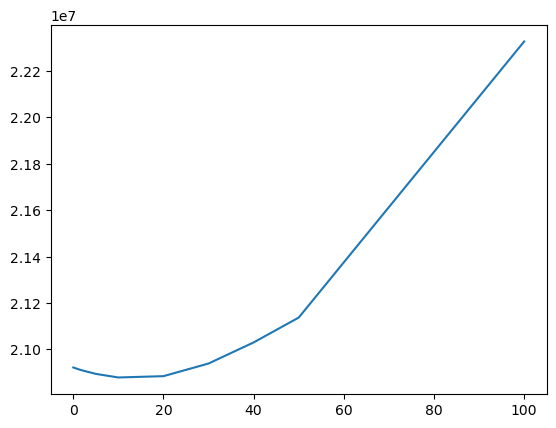

In [17]:
# lasso regression...

alphas = [0.001,0.1,1,2,5,10,20,30,40,50,100]
mses=[]
for a in alphas:
    lasso_model = Lasso(alpha = a)
    lasso_model.fit(x_train,y_train)
    y_pred = lasso_model.predict(x_test)
    mse = mean_squared_error(y_test,y_pred)
    print("mse for alphas {a} :  ",mse)
    mses.append(mse)

sns.lineplot(x=alphas,y=mses)